In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
print(os.listdir('/kaggle/input/datasets/ipythonx/mvtec-ad'))

['wood', 'screw', 'metal_nut', 'capsule', 'readme.txt', 'hazelnut', 'carpet', 'pill', 'license.txt', 'grid', 'zipper', 'transistor', 'tile', 'leather', 'toothbrush', 'bottle', 'cable']


In [5]:
!git clone https://github.com/hq-deng/RD4AD.git
%cd RD4AD
!pip install -q timm

Cloning into 'RD4AD'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 68 (delta 39), reused 31 (delta 31), pack-reused 25 (from 1)
Receiving objects: 100% (68/68), 26.21 KiB | 2.62 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/kaggle/working/RD4AD


In [7]:
# main.py에서 경로 하드코딩된 부분 고치기
!sed -i "s|'./mvtec'|'/kaggle/input/datasets/ipythonx/mvtec-ad'|g" main.py

In [10]:
!sed -i "s|'./mvtec/'|'/kaggle/input/datasets/ipythonx/mvtec-ad/'|g" main.py

# 확인
!grep -n "mvtec" main.py

72:    train_path = '/kaggle/input/datasets/ipythonx/mvtec-ad/' + _class_ + '/train'
73:    test_path = '/kaggle/input/datasets/ipythonx/mvtec-ad/' + _class_


In [17]:
!sed -i '118d' main.py
!cat -n main.py | sed -n '115,122p'

   115	
   116	    setup_seed(111)
   117	    item_list = ['hazelnut']
   118	    for i in item_list:
   119	        train(i)
   120	


In [14]:
!sed -i "s|item_list = \['carpet'.*|item_list = ['hazelnut']|" main.py
!grep -n "item_list" main.py

117:    item_list = ['hazelnut']
119:    for i in item_list:


In [20]:
# 1. df.append 오류 수정
# pandas import 추가
!sed -i '1s/^/import pandas as pd\n/' test.py

# df.append 수정
!sed -i 's/df = df.append(\(.*\), ignore_index=True)/df = pd.concat([df, pd.DataFrame([\1])], ignore_index=True)/g' test.py

# 확인
!head -3 test.py
!grep -n "append\|concat" test.py

import pandas as pd
import torch
from dataset import get_data_transforms, load_data
41:        a_map_list.append(a_map)
89:                aupro_list.append(compute_pro(gt.squeeze(0).cpu().numpy().astype(int),
93:            gt_list_sp.append(np.max(gt.cpu().numpy().astype(int)))
94:            pr_list_sp.append(np.max(anomaly_map))
179:            #inputs.append(feature)
180:            #inputs.append(outputs)
319:            prmax_list_sp.append(np.max(anomaly_map))
320:            prmean_list_sp.append(np.sum(anomaly_map))  # np.sum(anomaly_map.ravel().argsort()[-1:][::-1]))
373:                pros.append(tp_pixels / region.area)
379:        df = pd.concat([df, pd.DataFrame([{"pro": mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)
412:            prmax_list_sp.append(np.max(anomaly_map))
413:            prmean_list_sp.append(np.sum(anomaly_map))#np.sum(anomaly_map.ravel().argsort()[-1:][::-1]))


In [21]:
!python main.py \
    --data_path /kaggle/input/datasets/ipythonx/mvtec-ad \
    --category hazelnut \
    --epochs 200

hazelnut
cuda
epoch [1/200], loss:0.9403
epoch [2/200], loss:0.5697
epoch [3/200], loss:0.4697
epoch [4/200], loss:0.4164
epoch [5/200], loss:0.3809
epoch [6/200], loss:0.3516
epoch [7/200], loss:0.3285
epoch [8/200], loss:0.3135
epoch [9/200], loss:0.3017
epoch [10/200], loss:0.2918
/kaggle/working/RD4AD/test.py:379: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{"pro": mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)
/kaggle/working/RD4AD/test.py:379: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude

In [22]:
!mkdir -p checkpoints
!python main.py \
    --data_path /kaggle/input/datasets/ipythonx/mvtec-ad \
    --category hazelnut \
    --epochs 40

hazelnut
cuda
epoch [1/200], loss:0.9403
epoch [2/200], loss:0.5697
epoch [3/200], loss:0.4697
epoch [4/200], loss:0.4164
epoch [5/200], loss:0.3809
epoch [6/200], loss:0.3516
epoch [7/200], loss:0.3285
epoch [8/200], loss:0.3135
epoch [9/200], loss:0.3017
epoch [10/200], loss:0.2918
/kaggle/working/RD4AD/test.py:379: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{"pro": mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)
/kaggle/working/RD4AD/test.py:379: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude

✅ CSV 저장 완료
         date  category      backbone  epochs  i_auroc  p_auroc    pro  \
0  2026-05-06  hazelnut  wideresnet50     200      1.0    0.989  0.955   

                                    note  
0  paper default settings, Kaggle T4 GPU  
✅ 모델 로드 완료


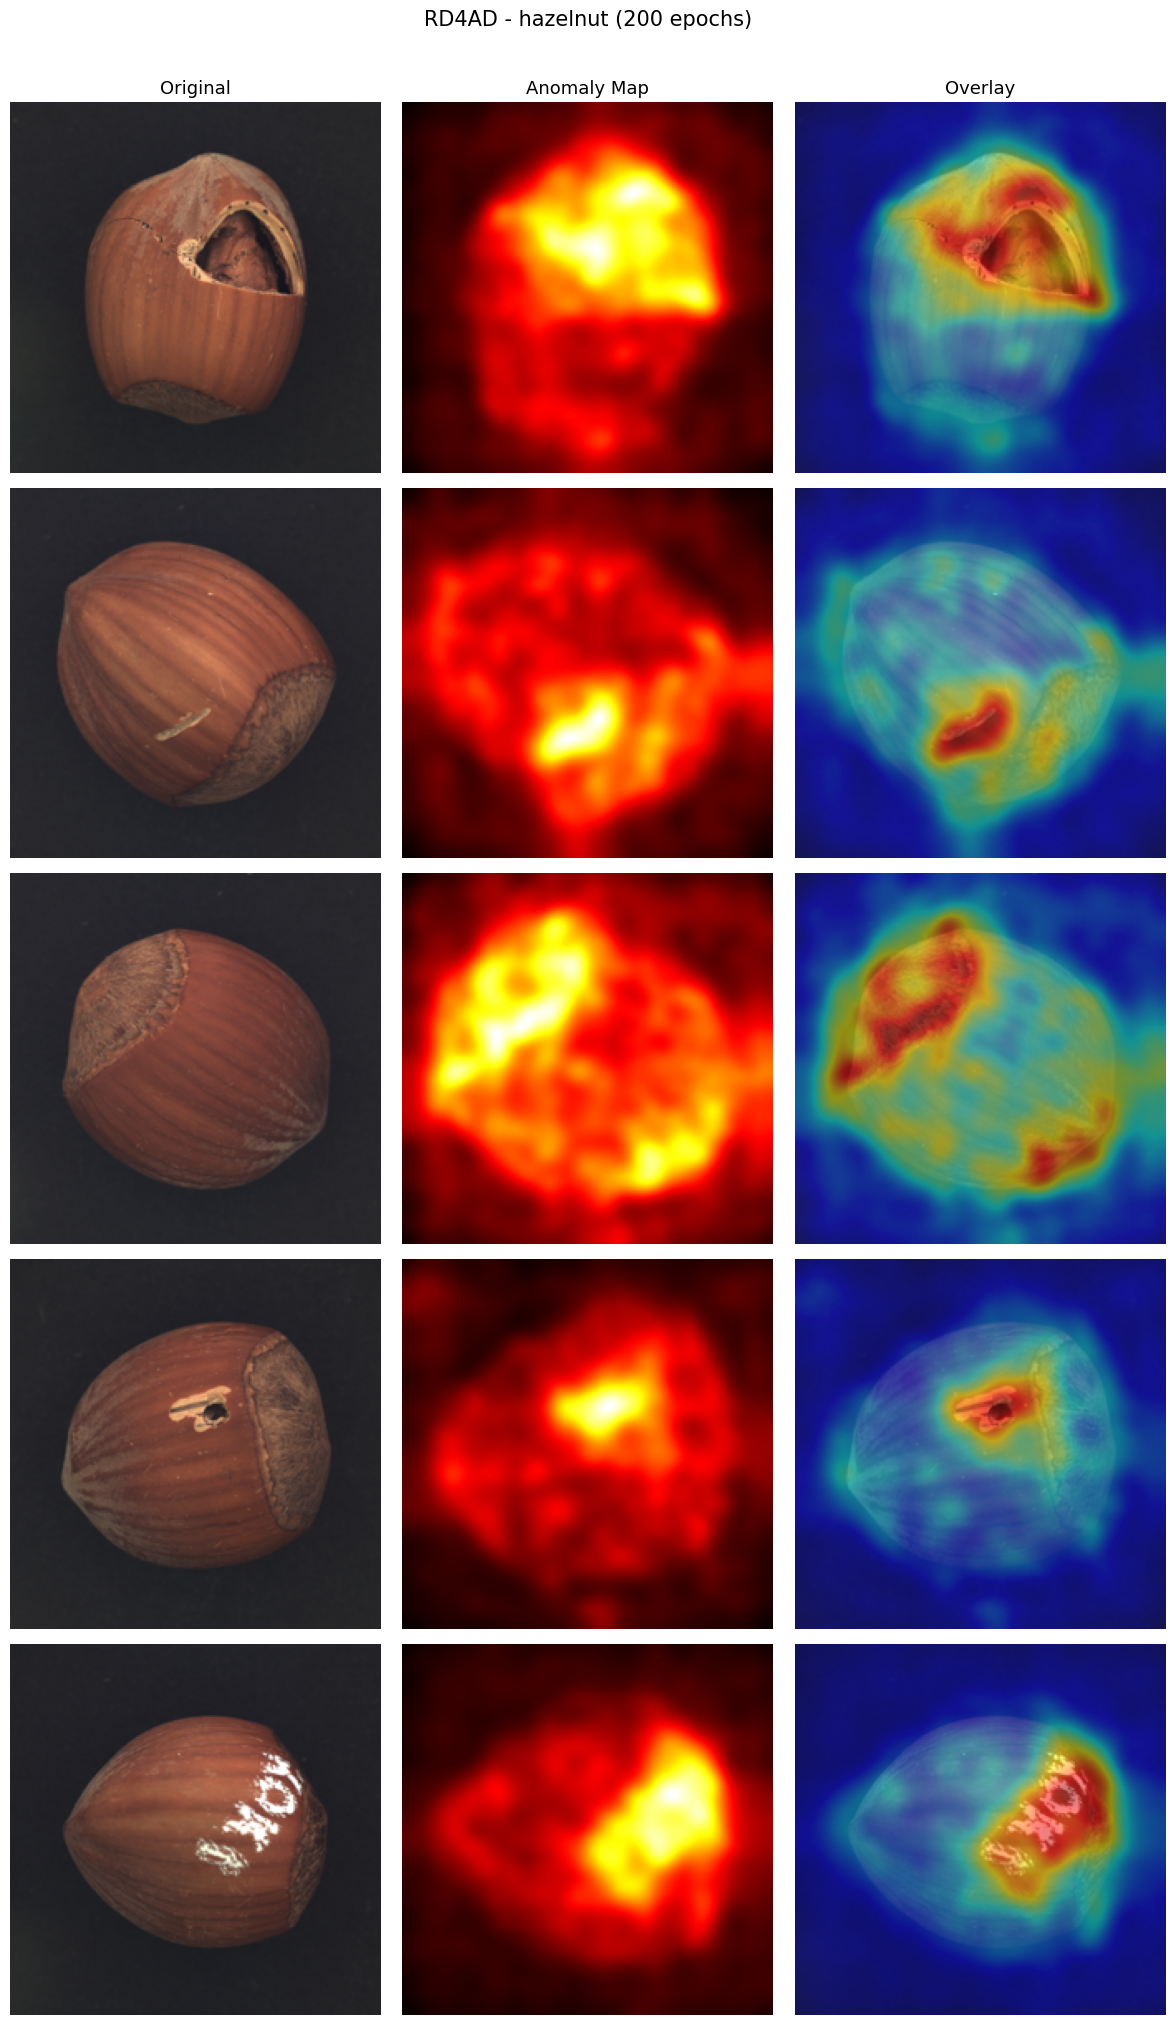

✅ 시각화 저장 완료


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import sys
import torch
import torch.nn.functional as F
from datetime import date
from PIL import Image
from scipy.ndimage import gaussian_filter
import torchvision.transforms as transforms

sys.path.append('/kaggle/working/RD4AD')
from resnet import wide_resnet50_2
from de_resnet import de_wide_resnet50_2

# ---- 1. CSV 저장 ----
df = pd.DataFrame([{
    'date': str(date.today()),
    'category': 'hazelnut',
    'backbone': 'wideresnet50',
    'epochs': 200,
    'i_auroc': 1.000,
    'p_auroc': 0.989,
    'pro': 0.955,
    'note': 'paper default settings, Kaggle T4 GPU'
}])
df.to_csv('/kaggle/working/rd_hazelnut_20260507.csv', index=False)
print("✅ CSV 저장 완료")
print(df)

# ---- 2. 모델 로드 ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder, bn = wide_resnet50_2(pretrained=True)
encoder = encoder.to(device).eval()
bn = bn.to(device).eval()
decoder = de_wide_resnet50_2()
decoder = decoder.to(device).eval()

ckp = torch.load('/kaggle/working/RD4AD/checkpoints/wres50_hazelnut.pth', map_location=device)
decoder.load_state_dict(ckp['decoder'])
bn.load_state_dict(ckp['bn'])
print("✅ 모델 로드 완료")

# ---- 3. 전처리 ----
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ---- 4. 이상 맵 계산 함수 ----
def get_anomaly_map(img_tensor):
    with torch.no_grad():
        inputs = encoder(img_tensor)
        outputs = decoder(bn(inputs))
    anomaly_map = 0
    for inp, out in zip(inputs, outputs):
        a_map = 1 - F.cosine_similarity(inp, out, dim=1)
        a_map = F.interpolate(
            a_map.unsqueeze(1), size=(224, 224),
            mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        anomaly_map += a_map
    return gaussian_filter(anomaly_map, sigma=4)

# ---- 5. 시각화 ----
test_base = '/kaggle/input/datasets/ipythonx/mvtec-ad/hazelnut/test'
defect_types = sorted([d for d in os.listdir(test_base)
                       if os.path.isdir(os.path.join(test_base, d))])

fig, axes = plt.subplots(len(defect_types), 3,
                         figsize=(12, 4 * len(defect_types)))
for ax, col in zip(axes[0], ['Original', 'Anomaly Map', 'Overlay']):
    ax.set_title(col, fontsize=13)

for row, defect in enumerate(defect_types):
    defect_path = os.path.join(test_base, defect)
    img_file = sorted(os.listdir(defect_path))[0]
    img_path = os.path.join(defect_path, img_file)

    orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

    anomaly_map = get_anomaly_map(img_tensor)
    anomaly_norm = (anomaly_map - anomaly_map.min()) / (anomaly_map.max() - anomaly_map.min() + 1e-8)

    heat = cv2.applyColorMap((anomaly_norm * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    overlay = (np.array(orig_img) * 0.5 + heat * 0.5).astype(np.uint8)

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_ylabel(defect, fontsize=11)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(anomaly_norm, cmap='hot')
    axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

plt.suptitle('RD4AD - hazelnut (200 epochs)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/rd_hazelnut_heatmap_20260507.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 시각화 저장 완료")